## Importing the relevant libraries

In [201]:
!pip install symspellpy scikit-learn-intelex yellowbrick

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 10.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 45.4 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.0/32.0 MB 24.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 53.2 MB/s eta 0:00:0000:01m00:01
  Attempting uninstall: tbb
    Found existing installation: tbb 2022.3.1
    Uninstalling tbb-2022.3.1:
      Successfully uninstalled tbb-2022.3.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mkl 2025.3.1 requires tbb==2022.*, but you have tbb 2023.1.0 which is incompatible.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [6]:
%matplotlib inline
import warnings, string, nltk, random, gc, joblib
warnings.filterwarnings('ignore')
# from sklearnex import patch_sklearn
# patch_sklearn()

In [7]:
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [8]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV

In [30]:
from symspellpy import SymSpell, Verbosity
from wordcloud import WordCloud
from tqdm.notebook import tqdm
tqdm.pandas()
from yellowbrick.classifier import ClassPredictionError


In [31]:
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

In [9]:
nltk.download('omw-1.4')

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Loading the dataset

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [94]:
df = pd.read_csv('/content/drive/MyDrive/Future_ML_Dataset/tickets_dataset.csv')
df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


## Data Exploration

In [95]:
df.shape

(47837, 2)

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Document     47837 non-null  object
 1   Topic_group  47837 non-null  object
dtypes: object(2)
memory usage: 747.6+ KB


In [97]:
df.describe()

,Document,Topic_group
count,47837,47837
unique,47837,8
top,running out on extensions hello please be advi...,Hardware
freq,1,13617


In [98]:
df.isna().sum()

,0
Document,0
Topic_group,0


In [99]:
df.duplicated().sum()

np.int64(0)

In [100]:
df = df.dropna()
df.shape

(47837, 2)

In [101]:
# renamed columns
df.rename({'Document': 'ticket_text', 'Topic_group': 'topic'},axis=1,inplace=True)

In [102]:
df.columns

Index(['ticket_text', 'topic'], dtype='object')

In [103]:
df['num_words'] = df["ticket_text"].apply(len)
df.num_words.describe()

,num_words
count,47837.000000
mean,291.881263
std,388.171200
min,7.000000
25%,110.000000
50%,175.000000
75%,304.000000
max,7015.000000


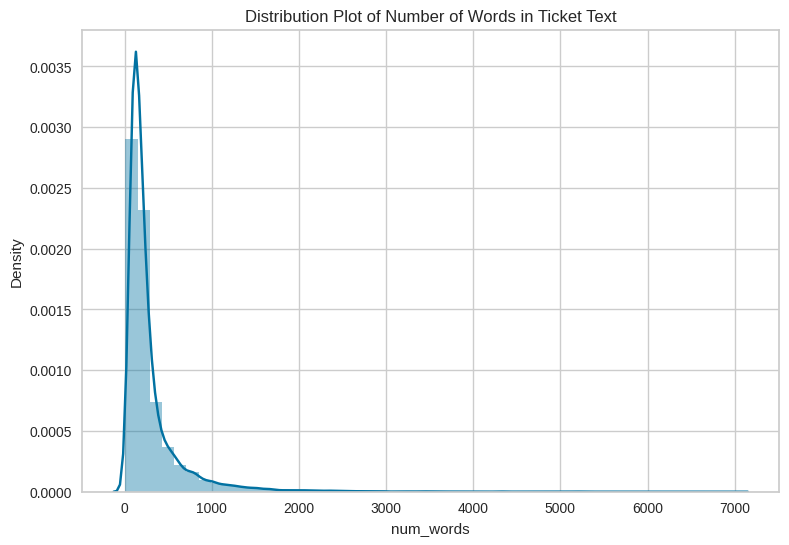

In [104]:
plt.figure(figsize=(9,6))
sns.distplot(df['num_words'])
plt.title('Distribution Plot of Number of Words in Ticket Text')
plt.show();

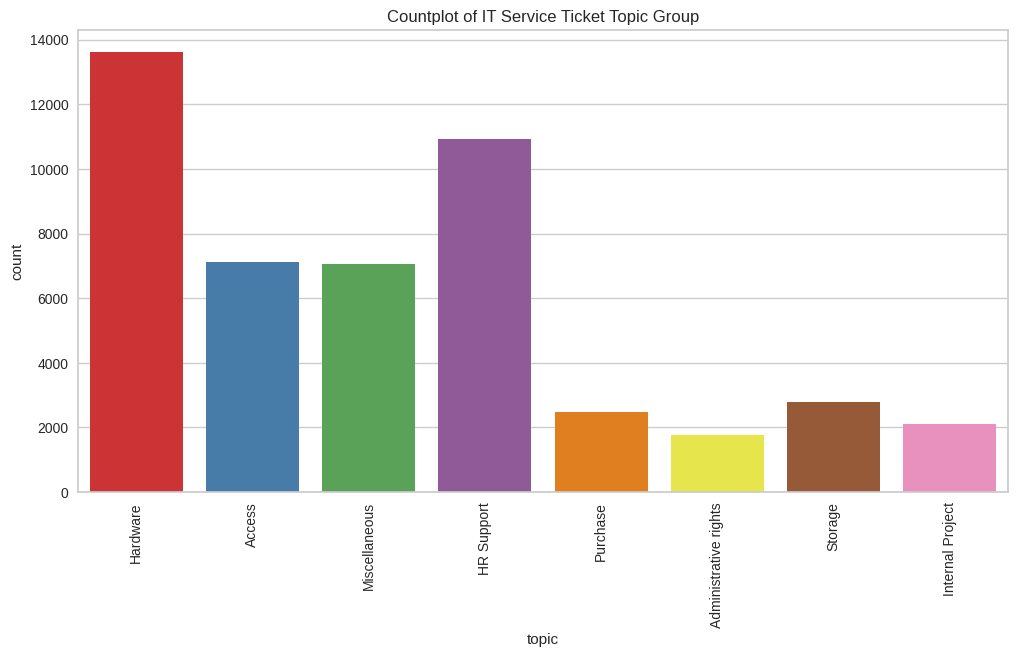

In [105]:
plt.figure(figsize=(12,6))
sns.countplot(data=df,x='topic',palette='Set1')
plt.xticks(rotation=90)
plt.title('Countplot of IT Service Ticket Topic Group')
plt.show();

In [106]:
df['topic'].value_counts()

,count
topic,
Hardware,13617
HR Support,10915
Access,7125
Miscellaneous,7060
Storage,2777
Purchase,2464
Internal Project,2119
Administrative rights,1760


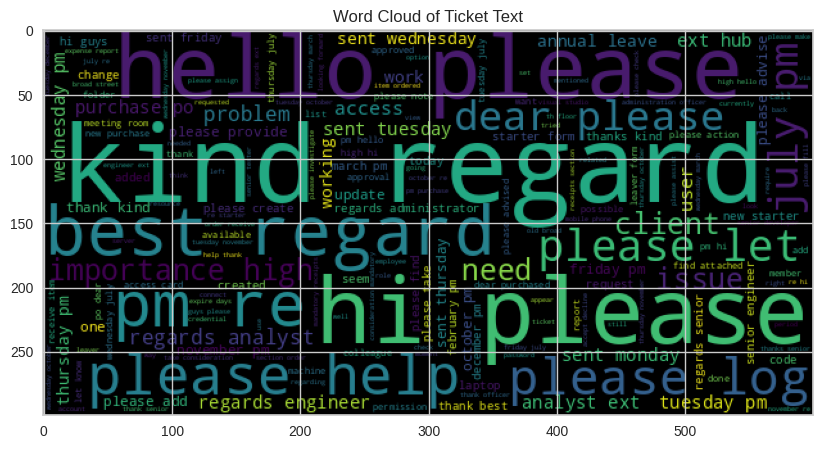

In [107]:
plt.figure(figsize=(12,5))
wc = WordCloud(width=600,height=300,random_state=101).generate(' '.join(df['ticket_text']))
plt.imshow(wc)
plt.title('Word Cloud of Ticket Text')
plt.show()

## Text Preprocessing

In [108]:
def preprocess_text(text):
    nopunc = [char.lower() for char in text if char not in string.punctuation]
    nopunc = ''.join(nopunc)
    return ' '.join([word for word in nopunc.split() if word not in stopwords.words('english') and not word.isdigit()])

In [109]:
symspell = SymSpell()

def fix_spelling_mistakes(text):
    corrected_spellings = []

    for token in text.split():
        x = symspell.lookup(phrase=token,verbosity=Verbosity.CLOSEST,max_edit_distance=2,include_unknown=True)[0].__str__()
        y = x.split(',')[0]
        corrected_spellings.append(y)

    return ' '.join(corrected_spellings)

In [110]:
lemmatizer = WordNetLemmatizer()

def lemmatize_words(text):
    return ' '.join([lemmatizer.lemmatize(word) for word in text.split()])

In [111]:
df["ticket_text"] = df["ticket_text"].progress_apply(preprocess_text)
df["ticket_text"] = df["ticket_text"].progress_apply(fix_spelling_mistakes)
df["ticket_text"] = df["ticket_text"].progress_apply(lemmatize_words)

  0%|          | 0/47837 [00:00<?, ?it/s]

  0%|          | 0/47837 [00:00<?, ?it/s]

  0%|          | 0/47837 [00:00<?, ?it/s]

In [113]:
df

,ticket_text,topic,num_words
0,connection icon icon dear please setup icon pe...,Hardware,111
1,work experience user work experience user hi w...,Access,124
2,requesting meeting requesting meeting hi pleas...,Hardware,93
3,reset password external account expire day hi ...,Access,948
4,mail verification warning hi got attached plea...,Miscellaneous,115
...,...,...,...
47832,git space project issue adding user sent tuesd...,Access,889
47833,error sent july error hi guy help error appear...,Miscellaneous,126
47834,connection issue sent tuesday july connection ...,Hardware,398
47835,error cube report sent tuesday july error hell...,HR Support,372


## Categorical Encoding

In [114]:
encoder = LabelEncoder()
df["topic"] = encoder.fit_transform(df["topic"])
df["topic"].value_counts()

,count
topic,
3,13617
2,10915
0,7125
5,7060
7,2777
6,2464
4,2119
1,1760


In [115]:
encoded_labels = dict()

for idx, label in enumerate(encoder.classes_):
    encoded_labels[idx] = label

print(encoded_labels)

{0: 'Access', 1: 'Administrative rights', 2: 'HR Support', 3: 'Hardware', 4: 'Internal Project', 5: 'Miscellaneous', 6: 'Purchase', 7: 'Storage'}


In [117]:
class_weights = compute_class_weight(class_weight='balanced',classes=np.unique(df.topic),y=df.topic)
class_weight_dict = dict(zip(np.unique(df.topic),class_weights))
class_weight_dict

{np.int64(0): np.float64(0.8392456140350877),
 np.int64(1): np.float64(3.3975142045454545),
 np.int64(2): np.float64(0.5478355474118186),
 np.int64(3): np.float64(0.43912939707718296),
 np.int64(4): np.float64(2.821908919301557),
 np.int64(5): np.float64(0.8469723796033994),
 np.int64(6): np.float64(2.4267958603896105),
 np.int64(7): np.float64(2.1532679150162046)}

## Feature Splitting

In [118]:
X = df['ticket_text']
y = df['topic']

In [119]:
X.shape, y.shape

((47837,), (47837,))

## Performing train-test-split

In [120]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=101, stratify=y)

In [121]:
X_train.shape , X_test.shape

((33485,), (14352,))

In [49]:
gc.collect()

24

## Model Training & Evaluation

In [51]:
model_names = []
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
roc_auc_scores = []

In [53]:
# Define a Function where we just pass model as parameter

def train_and_evaluate_model(model):
    pipeline = Pipeline(steps=[
        ('tfidf', TfidfVectorizer()),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test) 
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.show()

    visualizer = ClassPredictionError(pipeline)
    visualizer.fit(X_train, y_train)
    visualizer.score(X_test, y_test)
    visualizer.show()
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_pred_proba, average='weighted', multi_class='ovr')
    
    model_names.append(str(model).split('(')[0])
    accuracy_scores.append(acc)
    precision_scores.append(prec)
    recall_scores.append(recall)
    f1_scores.append(f1)
    roc_auc_scores.append(roc_auc)
    
    gc.collect()
    
    return pipeline

Confusion Matrix:
[[1838   28   54   96   26   69    8   19]
 [   3  442    6   55    1   15    2    4]
 [  76   34 2652  223   72  154   15   49]
 [  80  186  222 3243   46  194   47   67]
 [   5    4   17   13  583   12    0    2]
 [  32   18   68  108   26 1824   10   32]
 [   3    5   10   28    2    7  681    3]
 [   6    9    3   23    3   15    1  773]]
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88      2138
           1       0.61      0.84      0.70       528
           2       0.87      0.81      0.84      3275
           3       0.86      0.79      0.82      4085
           4       0.77      0.92      0.84       636
           5       0.80      0.86      0.83      2118
           6       0.89      0.92      0.91       739
           7       0.81      0.93      0.87       833

    accuracy                           0.84     14352
   macro avg       0.81      0.87      0.84     14352
weighted avg      

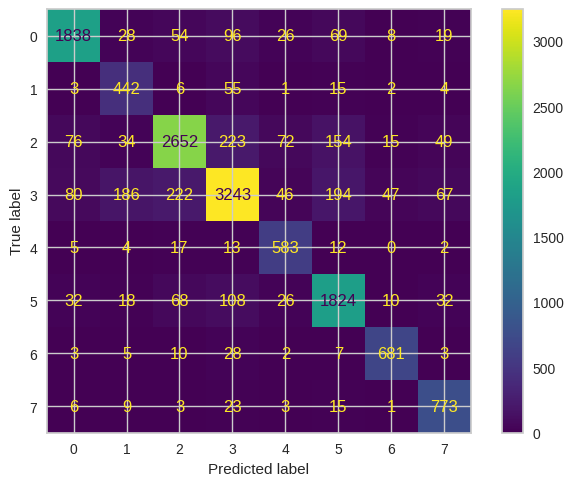

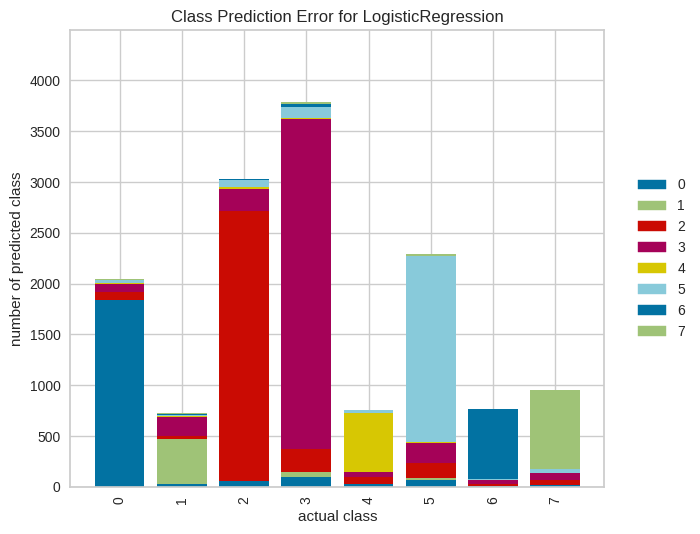

In [54]:
# Logistic Regression
lr_pipeline = train_and_evaluate_model(LogisticRegression(class_weight=class_weight_dict))

Confusion Matrix:
[[1709   23   82  202   22   76    7   17]
 [  14  367   13  102    1   19    3    9]
 [ 111   24 2468  363   76  185   14   34]
 [ 154  150  370 2909   62  301   49   90]
 [  15    5   32   40  501   42    0    1]
 [  72   21  186  282   44 1458   13   42]
 [   8    4   16   60    4   14  630    3]
 [  14    7   23   77    3   14    3  692]]
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81      2138
           1       0.61      0.70      0.65       528
           2       0.77      0.75      0.76      3275
           3       0.72      0.71      0.72      4085
           4       0.70      0.79      0.74       636
           5       0.69      0.69      0.69      2118
           6       0.88      0.85      0.86       739
           7       0.78      0.83      0.80       833

    accuracy                           0.75     14352
   macro avg       0.75      0.76      0.75     14352
weighted avg      

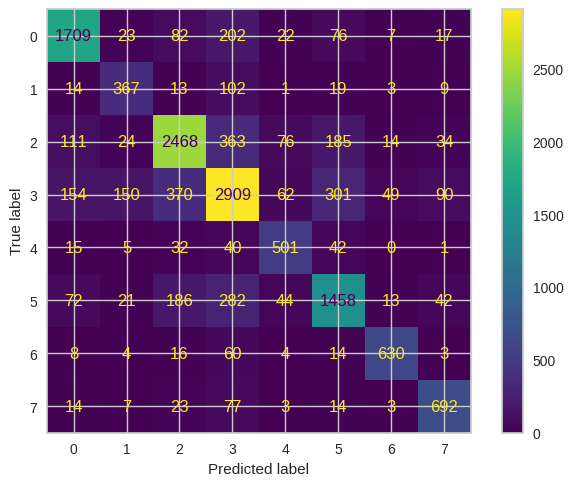

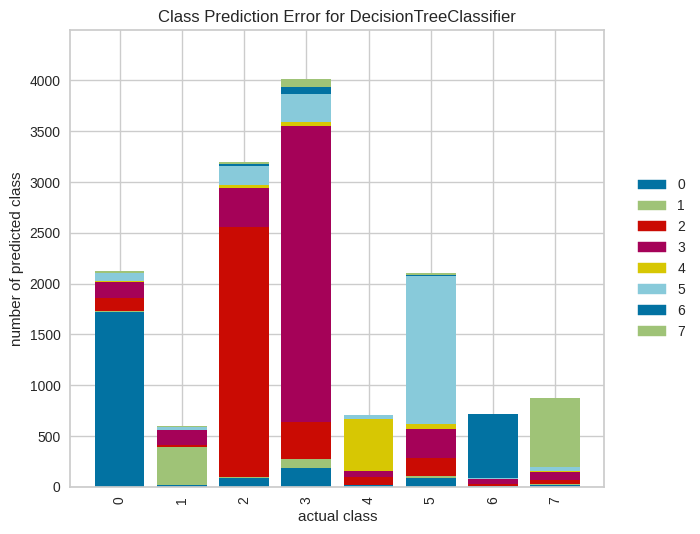

In [55]:
# Desicion Tree
dt_pipeline = train_and_evaluate_model(DecisionTreeClassifier(class_weight=class_weight_dict))

Confusion Matrix:
[[1481    0  195  389    1   71    0    1]
 [   9   80   15  416    0    8    0    0]
 [  63    0 2598  548    1   58    0    7]
 [  46    0  228 3728    0   73    7    3]
 [  20    0  200  126  215   75    0    0]
 [  34    0  295  449    0 1340    0    0]
 [   1    0   19  119    0    9  590    1]
 [  12    0   89  269    0   32    0  431]]
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.69      0.78      2138
           1       1.00      0.15      0.26       528
           2       0.71      0.79      0.75      3275
           3       0.62      0.91      0.74      4085
           4       0.99      0.34      0.50       636
           5       0.80      0.63      0.71      2118
           6       0.99      0.80      0.88       739
           7       0.97      0.52      0.68       833

    accuracy                           0.73     14352
   macro avg       0.87      0.60      0.66     14352
weighted avg      

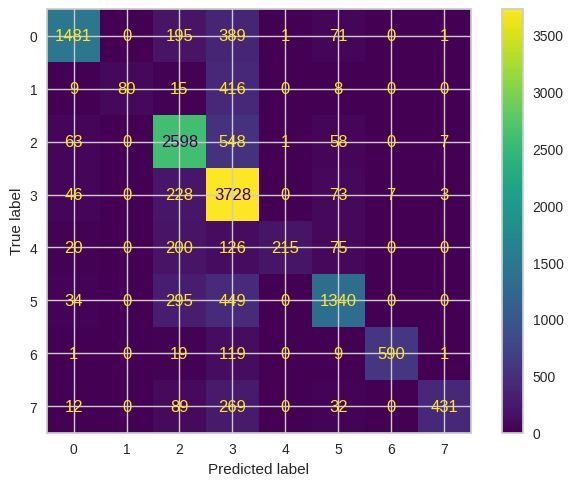

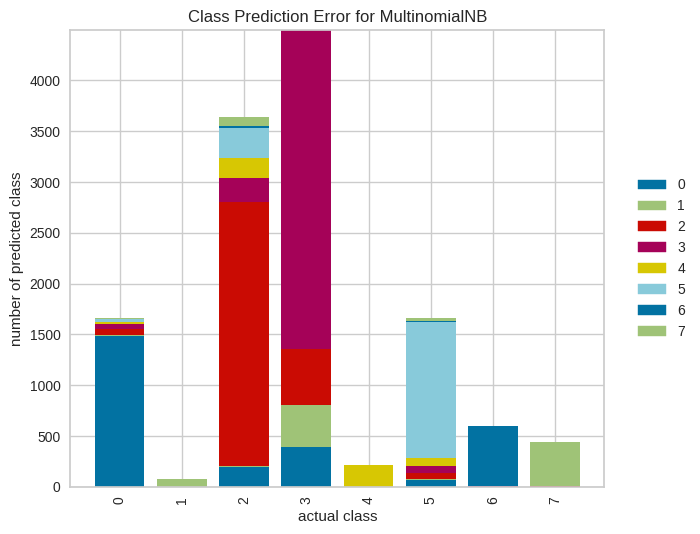

In [56]:
# Multinomial Naive Bayes
mnb_pipeline = train_and_evaluate_model(MultinomialNB())

Confusion Matrix:
[[1684    9  134  200   21   79    0   11]
 [ 102  207   53  117    2   38    0    9]
 [ 370    3 2456  183   24  179    2   58]
 [ 800   44  629 2244   23  263   18   64]
 [  67    0   96   26  381   63    0    3]
 [ 224    2  310  179   23 1354    1   25]
 [  28    1   37   41    1   21  608    2]
 [  46    4   72   92    3   38    0  578]]
Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.79      0.62      2138
           1       0.77      0.39      0.52       528
           2       0.65      0.75      0.70      3275
           3       0.73      0.55      0.63      4085
           4       0.80      0.60      0.68       636
           5       0.67      0.64      0.65      2118
           6       0.97      0.82      0.89       739
           7       0.77      0.69      0.73       833

    accuracy                           0.66     14352
   macro avg       0.73      0.65      0.68     14352
weighted avg      

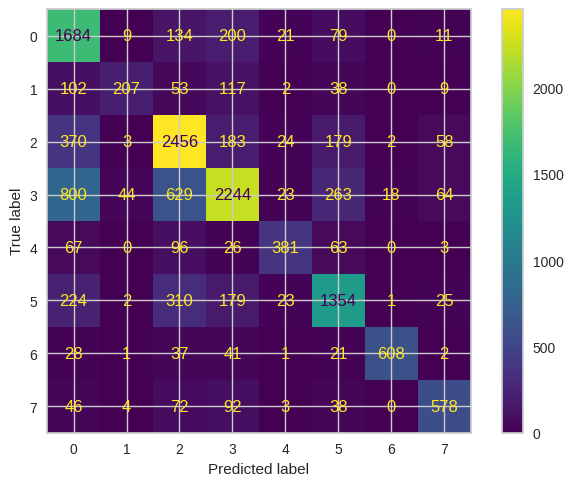

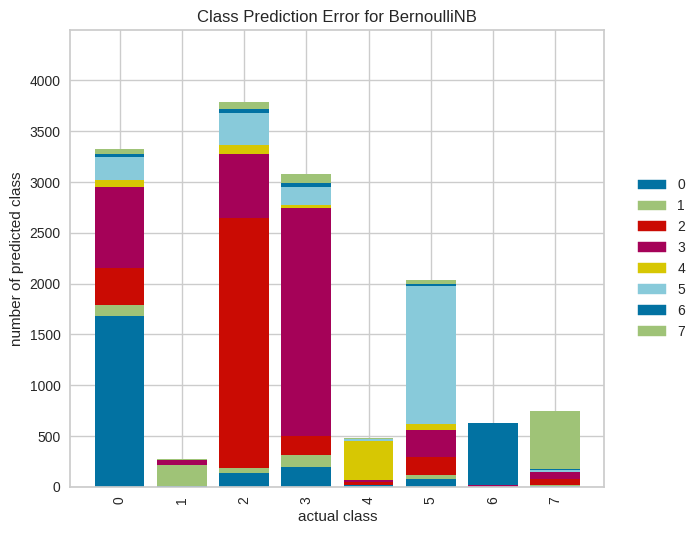

In [57]:
# Bernoulli Naive Bayes
bnb_pipeline = train_and_evaluate_model(BernoulliNB())

Confusion Matrix:
[[1879    3   53  138   12   39    2   12]
 [   6  372   10  116    2   14    3    5]
 [  46    7 2770  302   29   99    8   14]
 [  78   32  196 3587   20  122   21   29]
 [  11    0   29   37  532   25    2    0]
 [  43    6   95  245   19 1693    6   11]
 [   7    1   12   51    2    5  659    2]
 [  10    6   14   57    1   12    0  733]]
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      2138
           1       0.87      0.70      0.78       528
           2       0.87      0.85      0.86      3275
           3       0.79      0.88      0.83      4085
           4       0.86      0.84      0.85       636
           5       0.84      0.80      0.82      2118
           6       0.94      0.89      0.92       739
           7       0.91      0.88      0.89       833

    accuracy                           0.85     14352
   macro avg       0.87      0.84      0.86     14352
weighted avg      

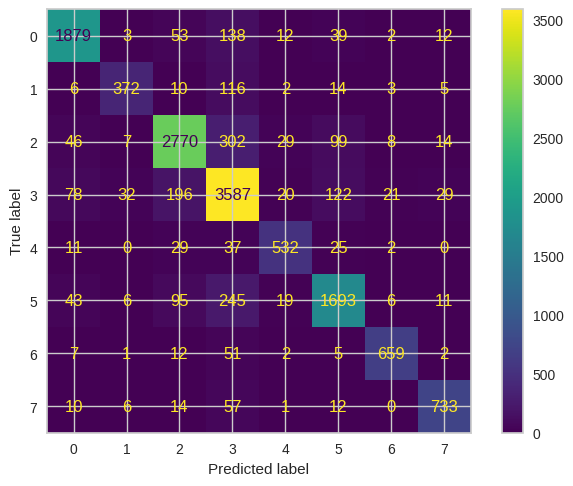

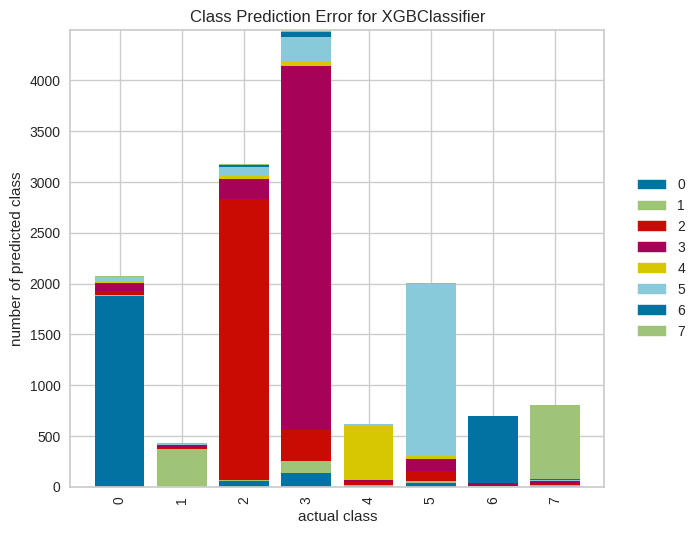

In [58]:
# XG Boost
xgb_pipeline = train_and_evaluate_model(XGBClassifier())

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.641795 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 173229
[LightGBM] [Info] Number of data points in the train set: 33485, number of used features: 2683
[LightGBM] [Info] Start training from score -1.904263
[LightGBM] [Info] Start training from score -3.302459
[LightGBM] [Info] Start training from score -1.477700
[LightGBM] [Info] Start training from score -1.256443
[LightGBM] [Info] Start training from score -3.117031
[LightGBM] [Info] Start training from score -1.913327
[LightGBM] [Info] Start training from score -2.965871
[LightGBM] [Info] Start training from score -2.846350
Confusion Matrix:
[[1906    4   47  124    7   42    1    7]
 [   6  377   11  109    2   15    3    5]
 [  45    6 2822  247   26  103    9   17]
 [  75   31  191 3610   19  121   17   21]
 [  11    2   26   33  540   24    0    0]
 [  36    9   87  186   15 1769    2   14]

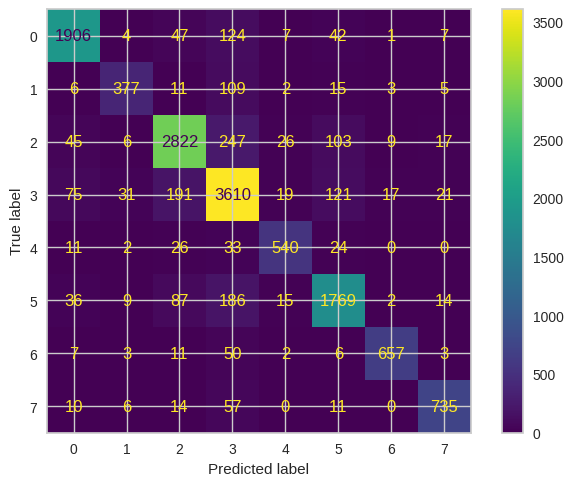

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.652101 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 173229
[LightGBM] [Info] Number of data points in the train set: 33485, number of used features: 2683
[LightGBM] [Info] Start training from score -1.904263
[LightGBM] [Info] Start training from score -3.302459
[LightGBM] [Info] Start training from score -1.477700
[LightGBM] [Info] Start training from score -1.256443
[LightGBM] [Info] Start training from score -3.117031
[LightGBM] [Info] Start training from score -1.913327
[LightGBM] [Info] Start training from score -2.965871
[LightGBM] [Info] Start training from score -2.846350


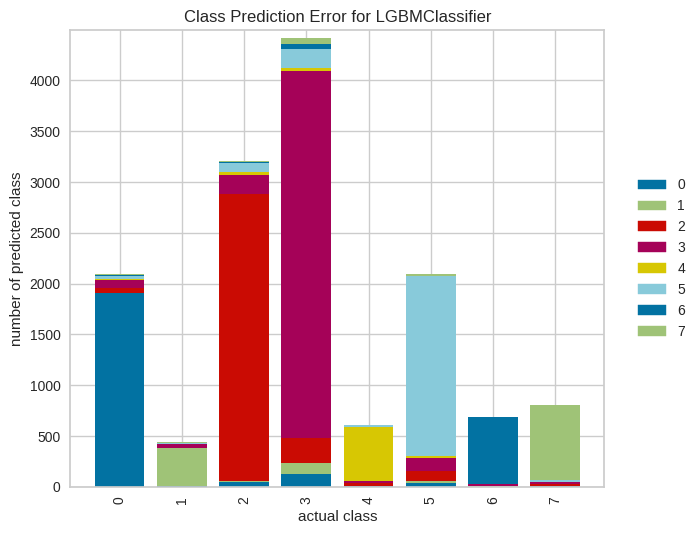

In [122]:
# Light Gradient Boosting Machine
lgbm_pipeline = train_and_evaluate_model(LGBMClassifier())

Confusion Matrix:
[[1734    0   90  236    4   64    2    8]
 [  14  262   19  208    1   19    2    3]
 [  43    1 2714  395   14   89    5   14]
 [  46   13  202 3697    5  100   11   11]
 [  10    0   53   83  457   32    0    1]
 [  31    3  120  285   11 1664    1    3]
 [   4    2   16   85    1    7  622    2]
 [  10    2   36  107    1   18    0  659]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.81      0.86      2138
           1       0.93      0.50      0.65       528
           2       0.84      0.83      0.83      3275
           3       0.73      0.91      0.81      4085
           4       0.93      0.72      0.81       636
           5       0.83      0.79      0.81      2118
           6       0.97      0.84      0.90       739
           7       0.94      0.79      0.86       833

    accuracy                           0.82     14352
   macro avg       0.88      0.77      0.82     14352
weighted avg      

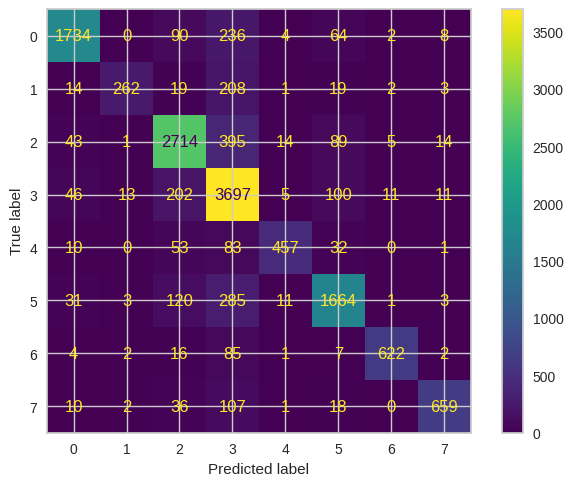

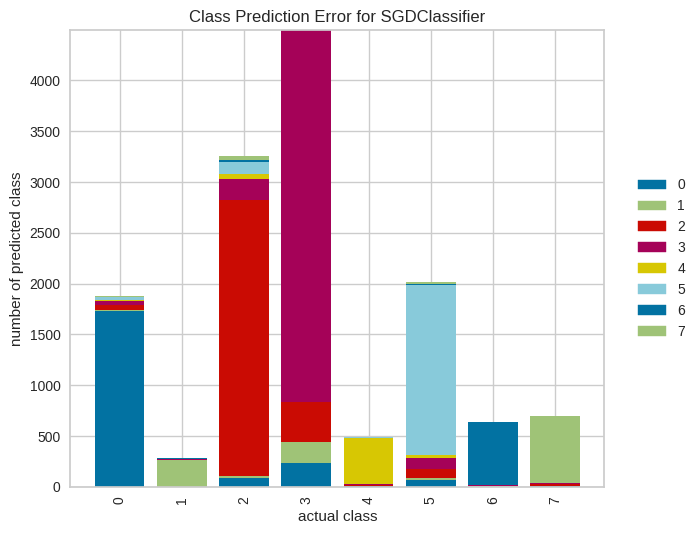

In [60]:
# SGD 

sgd_classifier = train_and_evaluate_model(SGDClassifier(loss='log_loss'))

Confusion Matrix:
[[1838    4   72  144    7   54    6   13]
 [   9  366   21  110    1   16    1    4]
 [  60   11 2774  274   28  103    7   18]
 [  69   38  239 3553   13  136   17   20]
 [   7    0   36   37  521   31    0    4]
 [  36    5  102  207   11 1743    4   10]
 [   5    2   15   39    1    4  670    3]
 [  10    6   10   64    2   17    0  724]]
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88      2138
           1       0.85      0.69      0.76       528
           2       0.85      0.85      0.85      3275
           3       0.80      0.87      0.83      4085
           4       0.89      0.82      0.85       636
           5       0.83      0.82      0.83      2118
           6       0.95      0.91      0.93       739
           7       0.91      0.87      0.89       833

    accuracy                           0.85     14352
   macro avg       0.87      0.84      0.85     14352
weighted avg      

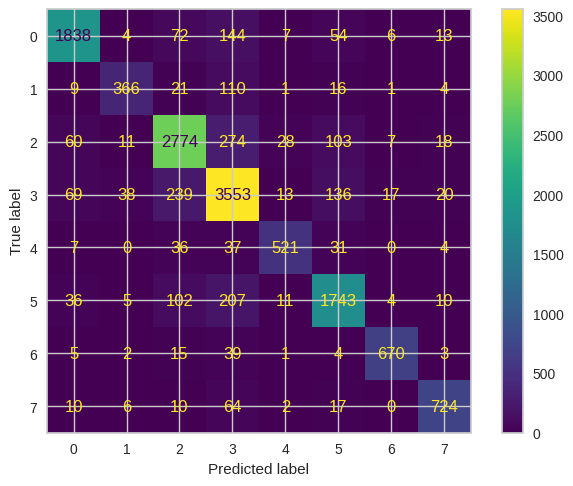

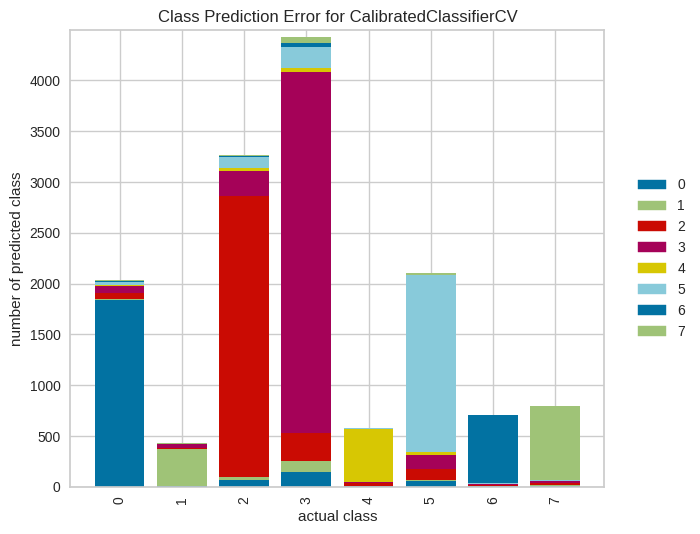

In [61]:
# LinearSVC

lsvc_pipeline = train_and_evaluate_model(CalibratedClassifierCV(LinearSVC(class_weight=class_weight_dict),method='sigmoid'))

## Model Performance Comparison

In [140]:
model_perfs = pd.DataFrame({
                            'Model': model_names,
                            'Accuracy': accuracy_scores,
                            'Precision': precision_scores,
                            'Recall': recall_scores,
                            'F1': f1_scores,
                            'ROC-AUC': roc_auc_scores
                            }).sort_values('Accuracy',ascending=False).reset_index(drop=True)
model_perfs

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,LGBMClassifier,0.865106,0.866788,0.865106,0.865197,0.982702
1,XGBClassifier,0.851798,0.854448,0.851798,0.851948,0.978866
2,CalibratedClassifierCV,0.849289,0.851319,0.849289,0.849430,0.975707
3,LogisticRegression,0.838629,0.844382,0.838629,0.839454,0.975811
4,SGDClassifier,0.822812,0.836217,0.822812,0.822549,0.975109
5,DecisionTreeClassifier,0.747910,0.749124,0.747910,0.748203,0.843375
6,MultinomialNB,0.729027,0.777651,0.729027,0.718230,0.949292
7,BernoulliNB,0.662765,0.686986,0.662765,0.662644,0.910056


From the above metrics we can say, the LGBMClassifier performed the best overall, with an accuracy of over 86% and a ROC-AUC score above 98%. It also handled the class imbalance well, giving a good balance between precision and recall. XGBoost and Calibrated LinearSVC also gave competitive results, while Logistic Regression and SGDClassifier provided good baseline performance with faster training times. MultinomialNB was the fastest among the models tested, but its recall was relatively low. Overall, the results show that LGBMClassifier was the most suitable model for this multiclass text classification task, especially when both precision and recall are important.


## Saving the best model

In [143]:
path = '/content/drive/MyDrive/Future_ML_Dataset'

with open(f'{path}/model.pkl', 'wb') as f:
    pickle.dump(lgbm_pipeline, f)

In [144]:
lgbm_pipeline.classes_

array([0, 1, 2, 3, 4, 5, 6, 7])

In [146]:
gc.collect()

0